# Ayudantía 6: Laboratorio 3 Parte 1

24 de Abril 2024

Juan Pablo Tapia

jp.tapia@uc.cl

## Cargar datos

In [1]:
!unzip datos.zip

Archive:  datos.zip
  inflating: accidentes.csv          
  inflating: vehiculos.csv           


In [18]:
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


## a)  Preparación de los datos

### Archivo: accidentes

In [3]:
accidentes = pd.read_csv('accidentes.csv')
display(accidentes)
display(accidentes.dtypes)
display(accidentes.dtypes.value_counts())
display(accidentes.isna().sum())

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Pedestrian_Crossing-Physical_Facilities,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,InScotland
0,2016010000005,A,4006.0,-,0.0,Slight,-,2016-11-01,Tuesday,Yes,...,0.0,Metropolitan Police,Dry,Single carriageway,-,30.0,02:30,Urban,Fine no high winds,No
1,2016010000006,A,207.0,Unclassified,0.0,Slight,-,2016-11-01,Tuesday,Yes,...,0.0,Metropolitan Police,Dry,Single carriageway,-,30.0,00:37,Urban,Fine no high winds,No
2,2016010000008,A,4020.0,A,4020.0,Slight,-,2016-11-01,Tuesday,Yes,...,0.0,Metropolitan Police,Dry,Roundabout,-,30.0,01:25,Urban,Fine no high winds,No
3,2016010000016,A,217.0,A,217.0,Slight,-,2016-11-01,Tuesday,Yes,...,0.0,Metropolitan Police,Dry,Single carriageway,-,30.0,09:15,Urban,Fine no high winds,No
4,2016010000018,A,312.0,-,0.0,Slight,-,2016-11-01,Tuesday,Yes,...,0.0,Metropolitan Police,Dry,Dual carriageway,-,40.0,07:53,Urban,Fine no high winds,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136616,2016984130916,B,7076.0,B,725.0,Slight,-,2016-10-28,Friday,Yes,...,0.0,Dumfries and Galloway,Wet or damp,Single carriageway,-,30.0,06:45,Rural,Fine no high winds,Yes
136617,2016984131116,B,7020.0,C,49.0,Slight,-,2016-11-01,Tuesday,Yes,...,0.0,Dumfries and Galloway,Dry,Single carriageway,-,60.0,16:45,Rural,Fine no high winds,Yes
136618,2016984131216,A(M),74.0,-,0.0,Slight,-,2016-10-27,Thursday,Yes,...,0.0,Dumfries and Galloway,Wet or damp,Dual carriageway,-,70.0,07:10,Rural,Fine no high winds,Yes
136619,2016984131316,B,724.0,-,0.0,Slight,-,2016-10-29,Saturday,Yes,...,0.0,Dumfries and Galloway,Dry,Single carriageway,-,40.0,20:00,Rural,Fine no high winds,Yes


,0
Accident_Index,object
1st_Road_Class,object
1st_Road_Number,float64
2nd_Road_Class,object
2nd_Road_Number,float64
Accident_Severity,object
Carriageway_Hazards,object
Date,object
Day_of_Week,object
Did_Police_Officer_Attend_Scene_of_Accident,object


,count
object,22
float64,9
int64,2


,0
Accident_Index,0
1st_Road_Class,0
1st_Road_Number,0
2nd_Road_Class,0
2nd_Road_Number,617
Accident_Severity,0
Carriageway_Hazards,0
Date,0
Day_of_Week,0
Did_Police_Officer_Attend_Scene_of_Accident,0


In [4]:
accidentes.dropna(inplace=True)
display(accidentes.isna().sum())

,0
Accident_Index,0
1st_Road_Class,0
1st_Road_Number,0
2nd_Road_Class,0
2nd_Road_Number,0
Accident_Severity,0
Carriageway_Hazards,0
Date,0
Day_of_Week,0
Did_Police_Officer_Attend_Scene_of_Accident,0


In [5]:
columnas1 = accidentes.columns
columnas_categoricas1 = columnas1[accidentes.dtypes == object]
columnas_numericas1 = columnas1[accidentes.dtypes != object]

label_encoder = LabelEncoder()
for col in columnas_categoricas1:
    accidentes[col] = label_encoder.fit_transform(accidentes[col])
display(accidentes.dtypes)
display(accidentes.dtypes.value_counts())

,0
Accident_Index,int64
1st_Road_Class,int64
1st_Road_Number,float64
2nd_Road_Class,int64
2nd_Road_Number,float64
Accident_Severity,int64
Carriageway_Hazards,int64
Date,int64
Day_of_Week,int64
Did_Police_Officer_Attend_Scene_of_Accident,int64


,count
int64,24
float64,9


### Archivo: vehiculos

In [6]:
vehiculos = pd.read_csv('vehiculos.csv')
display(vehiculos)
display(vehiculos.dtypes)
display(vehiculos.dtypes.value_counts())
display(vehiculos.isna().sum())

,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,...,Sex_of_Driver,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact
0,2016010000005,46 - 55,NaN,Urban area,3.0,NaN,-,-,Journey as part of work,Not at or within 20 metres of junction,...,Male,-,No tow/articulation,Did not leave carriageway,0.0,U-turn,1,Taxi/Private hire car,No,Offside
1,2016010000005,21 - 25,4.0,Urban area,4.0,124.0,-,-,Not known,Not at or within 20 metres of junction,...,Male,-,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,Motorcycle 50cc and under,No,Front
2,2016010000006,36 - 45,1.0,Urban area,10.0,1461.0,Kerb,-,Not known,Cleared junction or waiting/parked at junction...,...,Female,Skidded and overturned,No tow/articulation,Nearside,0.0,Going ahead other,1,Car,No,Nearside
3,2016010000008,21 - 25,5.0,Urban area,8.0,1390.0,-,-,Not known,Entering roundabout,...,Male,Overturned,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Car,No,Front
4,2016010000016,46 - 55,7.0,Urban area,9.0,6692.0,-,-,Journey as part of work,Approaching junction or waiting/parked at junc...,...,Male,-,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Bus or coach (17 or more pass seats),No,Did not impact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252495,2016984131116,21 - 25,14.0,Urban area,NaN,1598.0,-,-,Not known,Mid Junction - on roundabout or on main road,...,Female,-,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Car,No,Front
252496,2016984131116,56 - 65,NaN,Small town,NaN,1598.0,-,-,Commuting to/from work,Mid Junction - on roundabout or on main road,...,Female,-,No tow/articulation,Offside,0.0,Going ahead other,2,Car,No,Front
252497,2016984131216,56 - 65,NaN,Urban area,3.0,NaN,-,Central crash barrier,Journey as part of work,Not at or within 20 metres of junction,...,Male,-,No tow/articulation,Offside on to central reservation,0.0,Going ahead other,1,Goods 7.5 tonnes mgw and over,No,Offside
252498,2016984131316,16 - 20,13.0,Urban area,6.0,1796.0,-,Tree,Not known,Not at or within 20 metres of junction,...,Male,Skidded,No tow/articulation,Offside,0.0,Going ahead other,1,Car,No,Front


,0
Accident_Index,object
Age_Band_of_Driver,object
Age_of_Vehicle,float64
Driver_Home_Area_Type,object
Driver_IMD_Decile,float64
Engine_Capacity_.CC.,float64
Hit_Object_in_Carriageway,object
Hit_Object_off_Carriageway,object
Journey_Purpose_of_Driver,object
Junction_Location,object


,count
object,18
float64,4
int64,1


,0
Accident_Index,0
Age_Band_of_Driver,0
Age_of_Vehicle,68175
Driver_Home_Area_Type,0
Driver_IMD_Decile,67565
Engine_Capacity_.CC.,58780
Hit_Object_in_Carriageway,0
Hit_Object_off_Carriageway,0
Journey_Purpose_of_Driver,0
Junction_Location,0


In [7]:
vehiculos['Age_of_Vehicle'] = vehiculos['Age_of_Vehicle'].fillna(vehiculos['Age_of_Vehicle'].mean())
vehiculos['Driver_IMD_Decile'] = vehiculos['Driver_IMD_Decile'].fillna(vehiculos['Driver_IMD_Decile'].mean())
vehiculos['Engine_Capacity_.CC.'] = vehiculos['Engine_Capacity_.CC.'].fillna(vehiculos['Engine_Capacity_.CC.'].mean())
vehiculos['Vehicle_Location.Restricted_Lane'] = vehiculos['Vehicle_Location.Restricted_Lane'].fillna(vehiculos['Vehicle_Location.Restricted_Lane'].mean())
display(vehiculos.isna().sum())

,0
Accident_Index,0
Age_Band_of_Driver,0
Age_of_Vehicle,0
Driver_Home_Area_Type,0
Driver_IMD_Decile,0
Engine_Capacity_.CC.,0
Hit_Object_in_Carriageway,0
Hit_Object_off_Carriageway,0
Journey_Purpose_of_Driver,0
Junction_Location,0


In [8]:
columnas2 = vehiculos.columns
columnas_categoricas2 = columnas2[vehiculos.dtypes == object]
columnas_numericas2 = columnas2[vehiculos.dtypes != object]

label_encoder = LabelEncoder()
for col in columnas_categoricas2:
    vehiculos[col] = label_encoder.fit_transform(vehiculos[col])
display(vehiculos.dtypes)
display(vehiculos.dtypes.value_counts())

,0
Accident_Index,int64
Age_Band_of_Driver,int64
Age_of_Vehicle,float64
Driver_Home_Area_Type,int64
Driver_IMD_Decile,float64
Engine_Capacity_.CC.,float64
Hit_Object_in_Carriageway,int64
Hit_Object_off_Carriageway,int64
Journey_Purpose_of_Driver,int64
Junction_Location,int64


,count
int64,19
float64,4


## b) Identificación de patrones ocultos

In [9]:
columnas_accidentes = ['Number_of_Casualties','Number_of_Vehicles','Speed_limit','Light_Conditions','Weather_Conditions','Road_Surface_Conditions','Urban_or_Rural_Area']

df1 = accidentes[columnas_accidentes].copy()

for col in df1.select_dtypes(include='object'):
    df1[col] = LabelEncoder().fit_transform(df1[col].astype(str))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)

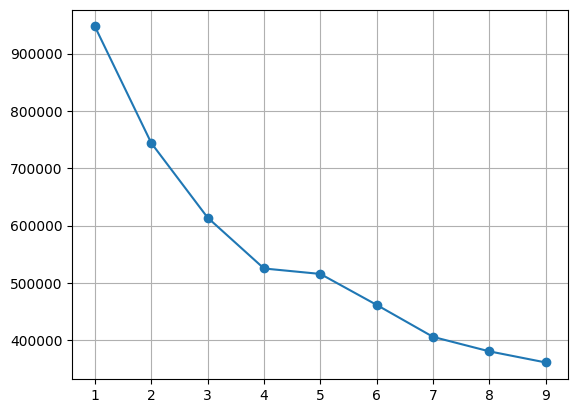

In [51]:
clusters = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    clusters.append(kmeans.inertia_)

plt.plot(range(1, 10), clusters, marker='o')
plt.grid(True)
plt.show()

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)
accidentes['Cluster'] = kmeans.fit_predict(X_scaled)

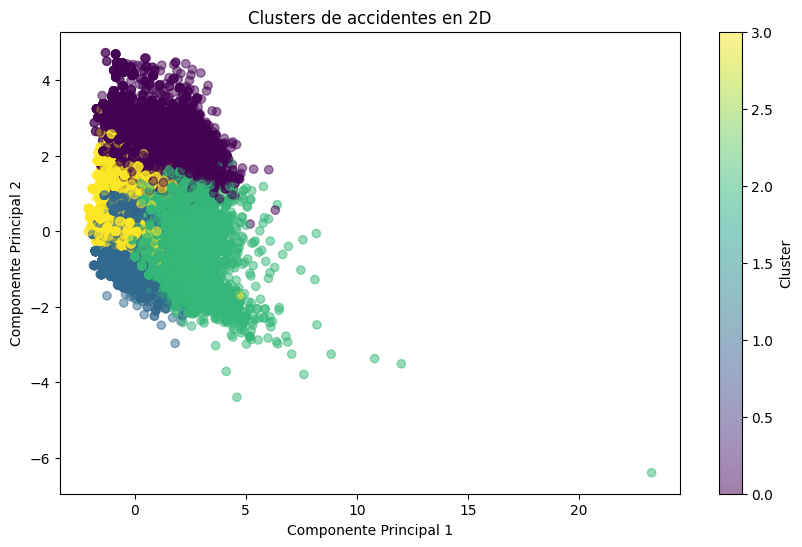

In [48]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=accidentes['Cluster'], cmap='viridis', alpha=0.5)
plt.title('Clusters de accidentes en 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.show()

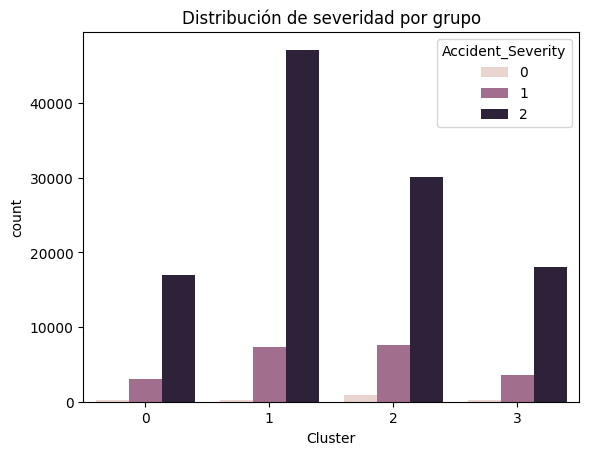

In [49]:
sns.countplot(data=accidentes, x='Cluster', hue='Accident_Severity')
plt.title('Distribución de severidad por grupo')
plt.show()

In [13]:
columnas_vehiculos = ['Age_Band_of_Driver','Age_of_Vehicle','Journey_Purpose_of_Driver','Vehicle_Manoeuvre','Skidding_and_Overturning','Vehicle_Leaving_Carriageway','Vehicle_Type']

df2 = vehiculos[columnas_vehiculos].copy()

for col in df2.select_dtypes(include='object'):
    df2[col] = LabelEncoder().fit_transform(df2[col].astype(str))

X_veh = StandardScaler().fit_transform(df2)

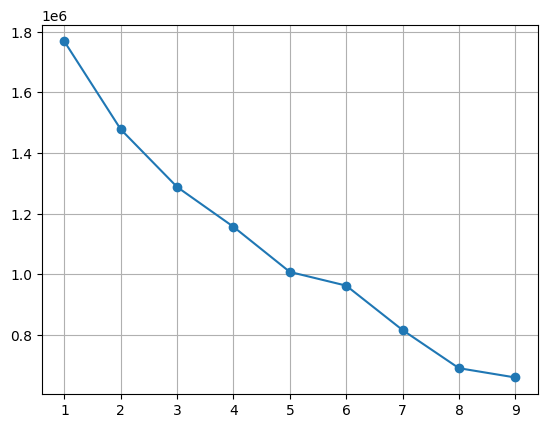

In [52]:
clusters = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_veh)
    clusters.append(kmeans.inertia_)

plt.plot(range(1, 10), clusters, marker='o')
plt.grid(True)
plt.show()

In [53]:
kmeans_veh = KMeans(n_clusters=5, random_state=42)
vehiculos['Cluster_Vehiculo'] = kmeans_veh.fit_predict(X_veh)

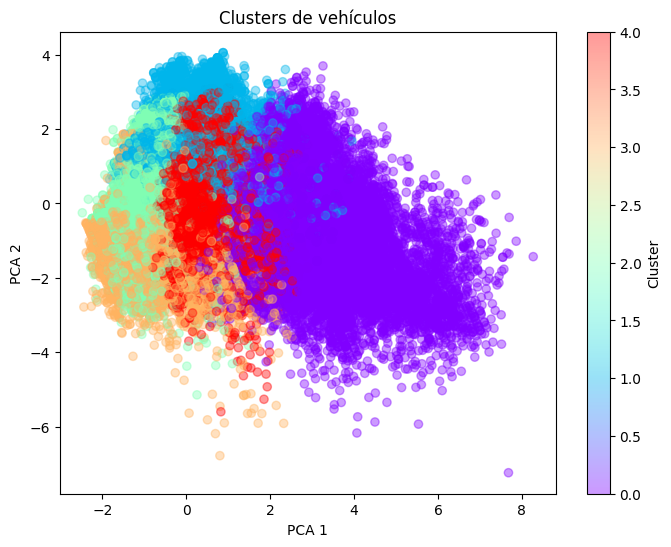

In [54]:
X_veh_pca = PCA(n_components=2).fit_transform(X_veh)
plt.figure(figsize=(8,6))
plt.scatter(X_veh_pca[:,0], X_veh_pca[:,1], c=vehiculos['Cluster_Vehiculo'], cmap='rainbow', alpha=0.4)
plt.title('Clusters de vehículos')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

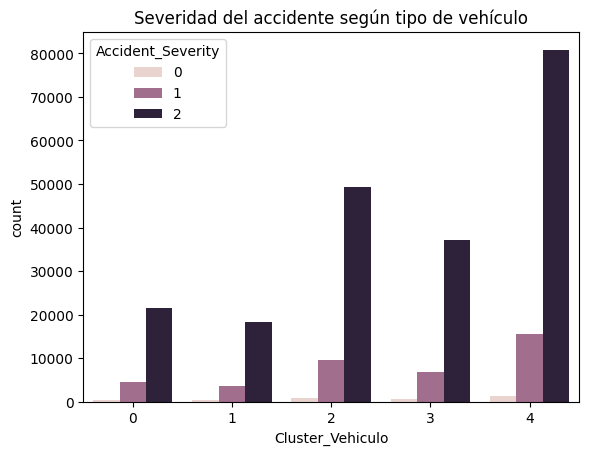

In [55]:
df_merge = pd.merge(vehiculos, accidentes[['Accident_Index', 'Accident_Severity']], on='Accident_Index')
sns.countplot(data=df_merge, x='Cluster_Vehiculo', hue='Accident_Severity')
plt.title('Severidad del accidente según tipo de vehículo')
plt.show()

## c) Variables temporales y desempeño predictivo

In [58]:
df = pd.merge(accidentes, vehiculos, on='Accident_Index')

# Variables temporales
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
df['Weekend'] = df['Date'].dt.dayofweek >= 5
df['Morning'] = df['Hour'].between(6, 12)

In [62]:
# Modelo base sin variables temporales
X_base = df[['Speed_limit', 'Age_Band_of_Driver', 'Engine_Capacity_.CC.', 'Age_of_Vehicle', 'Weather_Conditions']]
y = df['Accident_Severity']
X1_train, X1_test, y1_train, y1_test = train_test_split(X_base, y, random_state=42)

model_base = RandomForestClassifier(random_state=42)
model_base.fit(X1_train, y1_train)
print("Modelo sin variables temporales")
print(classification_report(y1_test, model_base.predict(X1_test)))

Modelo sin variables temporales
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       777
           1       0.18      0.05      0.07      9968
           2       0.83      0.96      0.89     51819

    accuracy                           0.80     62564
   macro avg       0.34      0.33      0.32     62564
weighted avg       0.72      0.80      0.75     62564



In [63]:
# Modelo con variables temporales
X_temp = df[['Speed_limit', 'Age_Band_of_Driver', 'Engine_Capacity_.CC.', 'Age_of_Vehicle', 'Weather_Conditions', 'Hour', 'Weekend', 'Morning']]
X2_train, X2_test, y2_train, y2_test = train_test_split(X_temp, y, random_state=42)

model_temp = RandomForestClassifier(random_state=42)
model_temp.fit(X2_train, y2_train)
print("Modelo con variables temporales")
print(classification_report(y2_test, model_temp.predict(X2_test)))

Modelo con variables temporales
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       777
           1       0.18      0.05      0.08      9968
           2       0.83      0.96      0.89     51819

    accuracy                           0.80     62564
   macro avg       0.34      0.33      0.32     62564
weighted avg       0.72      0.80      0.75     62564



## d) Escenarios hipotéticos iniciales

In [67]:
columnas = ['Speed_limit', 'Age_Band_of_Driver', 'Engine_Capacity_.CC.', 'Age_of_Vehicle', 'Weather_Conditions', 'Hour', 'Weekend', 'Morning']
ejemplos = df.sample(30, random_state=42)[columnas].copy()

In [68]:
def codificar_ejemplos(df):
    df_copy = df.copy()

    for col in df_copy.select_dtypes(include='bool').columns:
        df_copy[col] = df_copy[col].astype(int)

    for col in df_copy.select_dtypes(include=['object', 'category']).columns:
        df_copy[col] = LabelEncoder().fit_transform(df_copy[col].astype(str))

    return df_copy

ejemplos_codificados = codificar_ejemplos(ejemplos)
pred_original = model_temp.predict(ejemplos_codificados)

In [69]:
# Creamos una copia del escenario
escenario_modificado = ejemplos.copy()

# Aumentamos la velocidad máxima
escenario_modificado['Speed_limit'] = escenario_modificado['Speed_limit'] + 100

# Simulamos clima más adverso (por ejemplo, pasando a código 'lluvia fuerte')
escenario_modificado['Weather_Conditions'] = 3

# Volvemos a predecir
escenario_modificado_cod = codificar_ejemplos(escenario_modificado)
pred_modificado = model_temp.predict(escenario_modificado_cod)

In [70]:
resultados = pd.DataFrame({
    'Severidad original': pred_original,
    'Severidad modificada': pred_modificado
})
resultados.index = ['Accidente ' + str(i+1) for i in range(len(pred_original))]
resultados

,Severidad original,Severidad modificada
Accidente 1,2,2
Accidente 2,2,2
Accidente 3,2,2
Accidente 4,1,2
Accidente 5,2,2
Accidente 6,2,2
Accidente 7,2,2
Accidente 8,1,2
Accidente 9,2,2
Accidente 10,2,2


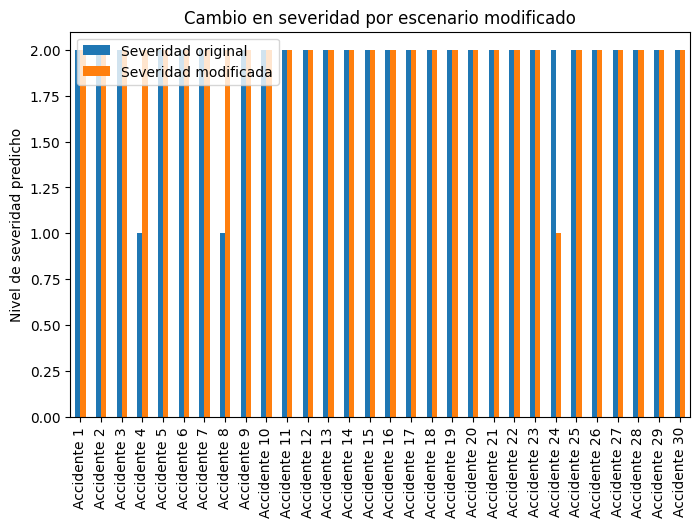

In [71]:
resultados.plot(kind='bar', figsize=(8,5), title='Cambio en severidad por escenario modificado')
plt.ylabel('Nivel de severidad predicho')
plt.show()